<a href="https://colab.research.google.com/github/aashutoshraj521/Computer-Vision/blob/main/Comparison_of_Edge_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

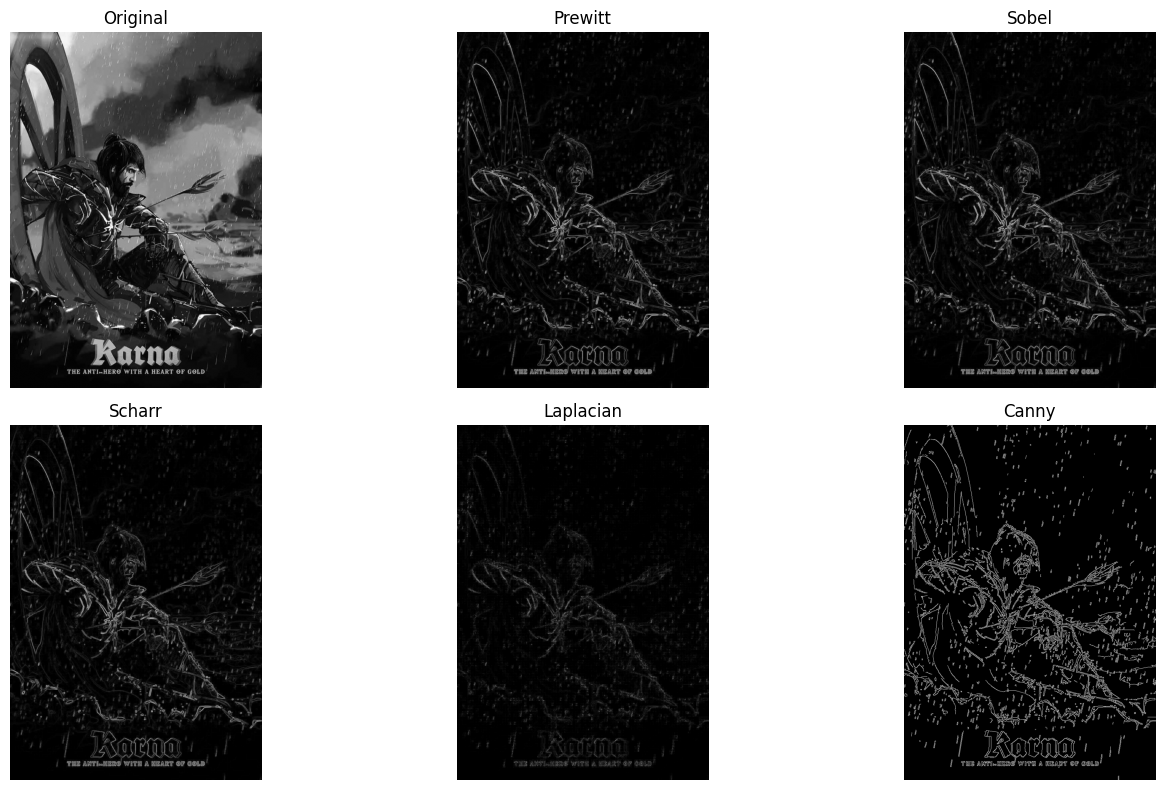

In [4]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Read image in grayscale
image = cv2.imread("/content/drive/MyDrive/Colab Notebooks/Computer Vision/karna.jpg", 0)

# --------------------
# Prewitt
# --------------------

kernel_x = np.array([
    [-1, 0, 1],
    [-1, 0, 1],
    [-1, 0, 1]
])

kernel_y = np.array([
    [-1, -1, -1],
    [ 0,  0,  0],
    [ 1,  1,  1]
])

prewitt_x = cv2.filter2D(image, cv2.CV_64F, kernel_x)
prewitt_y = cv2.filter2D(image, cv2.CV_64F, kernel_y)

prewitt = np.sqrt(
    prewitt_x**2 +
    prewitt_y**2
)

# --------------------
# Sobel
# --------------------

sobel_x = cv2.Sobel(image, cv2.CV_64F, 1, 0)
sobel_y = cv2.Sobel(image, cv2.CV_64F, 0, 1)

sobel = np.sqrt(
    sobel_x**2 +
    sobel_y**2
)

# --------------------
# Scharr
# --------------------

scharr_x = cv2.Scharr(image, cv2.CV_64F, 1, 0)
scharr_y = cv2.Scharr(image, cv2.CV_64F, 0, 1)

scharr = np.sqrt(
    scharr_x**2 +
    scharr_y**2
)

# --------------------
# Laplacian
# --------------------

laplacian = cv2.Laplacian(
    image,
    cv2.CV_64F
)

laplacian = np.abs(laplacian)

# --------------------
# Canny
# --------------------

canny = cv2.Canny(
    image,
    100,
    200
)

# --------------------
# Display
# --------------------

titles = [
    "Original",
    "Prewitt",
    "Sobel",
    "Scharr",
    "Laplacian",
    "Canny"
]

images = [
    image,
    prewitt,
    sobel,
    scharr,
    laplacian,
    canny
]

plt.figure(figsize=(15,8))

for i in range(len(images)):
    plt.subplot(2,3,i+1)
    plt.imshow(images[i], cmap='gray')
    plt.title(titles[i])
    plt.axis("off")

plt.tight_layout()
plt.show()

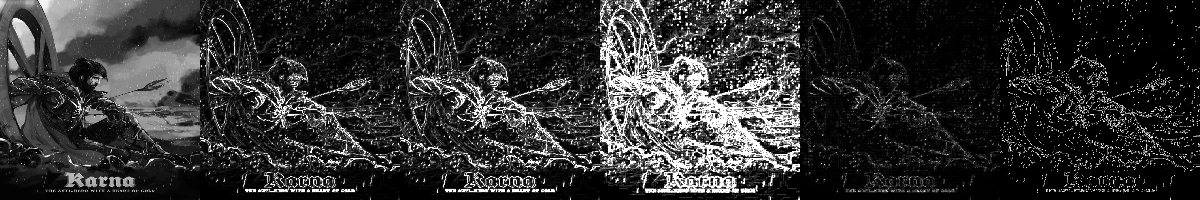

In [8]:
from google.colab.patches import cv2_imshow

# Resize all images
# --------------------
size = (200, 200)

original_r  = cv2.resize(image, size)

prewitt_r   = cv2.convertScaleAbs(cv2.resize(prewitt, size))
sobel_r     = cv2.convertScaleAbs(cv2.resize(sobel, size))
scharr_r    = cv2.convertScaleAbs(cv2.resize(scharr, size))
laplacian_r = cv2.convertScaleAbs(cv2.resize(laplacian, size))
canny_r     = cv2.resize(canny, size)

# --------------------
# Stack horizontally
# --------------------
comparison = np.hstack([
    original_r,
    prewitt_r,
    sobel_r,
    scharr_r,
    laplacian_r,
    canny_r
])

# Display
cv2_imshow(comparison)